In [32]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [33]:
#load dataset
df = pd.read_csv("Titanic-Dataset.csv")

print("First 5 Rows:")
print(df.head())

First 5 Rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN

In [34]:
# data Preprocessing

# Drop unnecessary columns
df = df.drop(['PassengerId','Name','Ticket','Cabin'], axis=1)

# Convert categorical variables to numeric
df['Sex'] = df['Sex'].map({'male':0, 'female':1})
df['Embarked'] = df['Embarked'].map({'S':0,'C':1,'Q':2})

# Fill missing values
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(0, inplace=True)

print("\nCleaned Dataset:")
print(df.head())


Cleaned Dataset:
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0         0       3    0  22.0      1      0   7.2500       0.0
1         1       1    1  38.0      1      0  71.2833       1.0
2         1       3    1  26.0      0      0   7.9250       0.0
3         1       1    1  35.0      1      0  53.1000       0.0
4         0       3    0  35.0      0      0   8.0500       0.0


/tmp/ipykernel_1050/1955598331.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_1050/1955598331.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

In [35]:
# Separate Features and Target
X = df.drop('Survived', axis=1)
y = df['Survived']

In [36]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [37]:
# Logistic Regression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

print("\nLogistic Regression Accuracy:", accuracy_score(y_test, y_pred))


Logistic Regression Accuracy: 0.7988826815642458


In [38]:
# Confussion Matrix

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Confusion Matrix:
[[89 16]
 [20 54]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



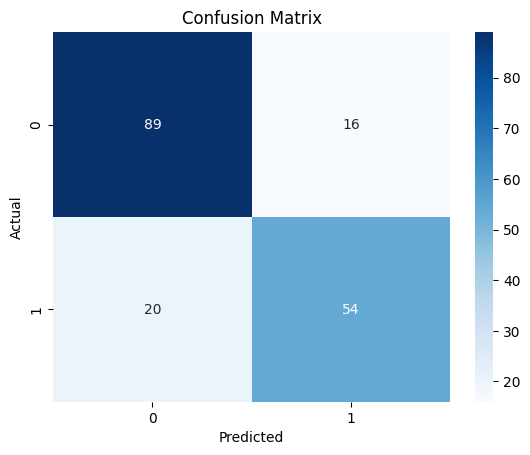

In [39]:
# Confussion Matrix Visualization

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [40]:
# Decision Tree Model

dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("\nDecision Tree Accuracy:", accuracy_score(y_test, dt_pred))


Decision Tree Accuracy: 0.7821229050279329


In [41]:
# Random forest Model

rf = RandomForestClassifier()

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("\nRandom Forest Accuracy:", accuracy_score(y_test, rf_pred))


Random Forest Accuracy: 0.8100558659217877


In [42]:
# Hyperparameter Tuning

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)

print("\nTuned Random Forest Accuracy:", accuracy_score(y_test, pred))


Tuned Random Forest Accuracy: 0.8100558659217877


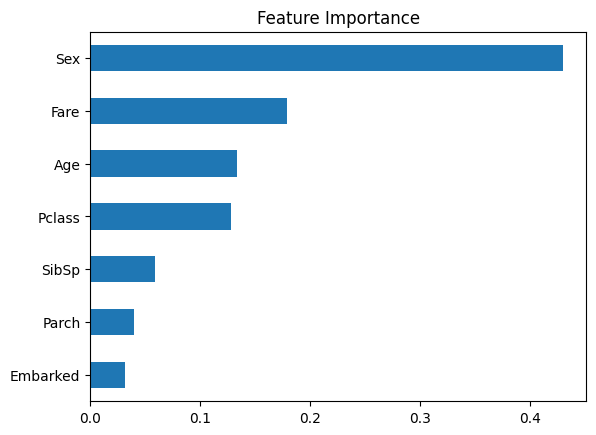

In [43]:
# Feature important

importance = rf.feature_importances_

features = pd.Series(importance, index=X.columns)

features.sort_values().plot(kind='barh')

plt.title("Feature Importance")

plt.show()

In [44]:
# Cross Validation

scores = cross_val_score(rf, X, y, cv=5)

print("\nCross Validation Accuracy:", scores.mean())


Cross Validation Accuracy: 0.8227041616973197


In [45]:
# Save the Model

pickle.dump(rf, open("titanic_random_forest.pkl", "wb"))

print("\nModel Saved Successfully!")


Model Saved Successfully!


In [1]:
sns.countplot(x='Survived', data=df)
plt.title("Survival Distribution")
plt.show()

NameError: name 'sns' is not defined

In [ ]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Survival by Gender")
plt.show()

In [ ]:
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title("Survival by Passenger Class")
plt.show()

In [ ]:
sns.histplot(df['Age'], bins=30)
plt.title("Age Distribution")
plt.show()